# XBTorch::Example 05:Hardware-Aware Training (HWA Training)

## Introduction

In this example, we will explore hardware-aware training capabilities provided by XBTorch. The particular example we'll focus on will be a two-layer perceptron network using the MNIST dataset, but any of these parts can be extended for other applications as needed. We will use WAGE quantization [1], which is a quantization-aware training scheme, in conjunction with a tabular device model for FeFET devices. The HWA training methodology is directly based on the algorithm presented in [2].

## Getting Started

Let's import necessary dependencies.

In [1]:
# General Imports
import numpy as np
import matplotlib.pyplot as plt
import random
import time
from pathlib import Path
import os
import pickle

import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [2]:
# XBTorch Imports
import xbtorch
import xbtorch.optim as xboptim
from xbtorch.patches import xbtorch_model
from xbtorch.devices import TabularCompactFeFETKriging
from xbtorch.nn.utils import test_classifier, train_classifier

from nets.mlp import SimpleMLP

No CUDA runtime is found, using CUDA_HOME='/usr/local/cuda'


Let's fix the seed for reproducibility, and initialize network and XBTorch-specific parameters.

In [3]:
seed = 0

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed) # controls weight updatejump table stochasticity

# Check if CUDA is available and select the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [4]:
# Network parameters
batch_size = 4096
epochs = 20
iterations = 10 # number of iterations/models to train

# learning rate when using WAGE (specified later)
lr_wage = 4.7579443140094098
lr_decay_rate_wage = 1

# learning rate without WAGE (no explicit quantization on weights, activations, gradients, or errors)
lr_sw = 0.1
lr_decay_rate_sw = 1

## Initialize XBTorch

In [5]:
# XBTorch parameters
xb_patch_network = True
xb_device_model = "tab_fefet_compact_vgs_0.9_sd_1" # device model name goes here
weight_range = (-1, +1) # number formats used in forward and backward quantization conversions

# WAGE quantization parameters (https://arxiv.org/pdf/1802.04680)
wage_quantize = xb_patch_network
wage_params = { "wl_weight": 2, # 2 = ternary weights
                "wl_grad": 8,
                "wl_activation": 8,
                "wl_error": 8,
                "rounding_weight" : "nearest",
                "rounding_activation" : "nearest",
                "rounding_grad" : "nearest",
                "rounding_error" : "nearest",
               }

In the cell above, we initalize various XBTorch parameters pertaining to hardware-aware training. Here's a quick summary of what everything means: 

| Parameter    | Purpose |
| -------- | ------- |
| `xb_patch_network`  | Whether or not the network should be patched    |
| `xb_device_model` | Name passed to XBTorch device model preset     |
| `weight_range`    | The absolute weight range used for conversions between weights and conductances    |
| `wage_quantize`    | Whether or not WAGE quantization should be utilized. Requires `xb_patch_network = True` |
| `wage_params`    | Parameter dictionary for individual parameters related to WAGE quantization |

The `xb_patch_network` can be set to `False` if one is interested in training a pure software network. The entire notebook can be re-run with that setting. This is often a great way to compare the performance of a hardware-aware training scheme, as we'll see in follow-up examples.

For more details on the API, view the full XBTorch documentation.

We can now initialize XBTorch. If a parameter is not provided, default values are utilized. The reader is directed to `XBParams.__init__()` for the underlying implementation.

In [6]:
# Init xbtorch
xb_device = TabularCompactFeFETKriging(xb_device_model)
xbtorch.initialize(device_type=xb_device,
                   pytorch_device=device,
                   weight_range=weight_range,
                   wage_quantize=wage_quantize,
                   wage_params=wage_params
                   )

## Prepare the dataset

We can now prepare the dataset for our neural network. For simplicity, we will stick to the MNIST dataset for this example.

In [7]:
# Define transforms to apply to the data
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert images to tensors
    transforms.Normalize((0.1307,), (0.3081,))  # Normalize the image data
])

# Load the MNIST training and test datasets
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Create data loaders for batching and shuffling
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator(device=device), num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=10000, shuffle=False, generator=torch.Generator(device=device), num_workers=4)

## Prepare the model

We will work with a simple 2-layer perceptron network. Example network implementations are provided in the `nets/` directory.

In [8]:
# Define the model
input_size = 28 * 28
hidden_size = 150
output_size = 10

# Model
model = SimpleMLP(input_size, hidden_size, output_size).to(device)
model

SimpleMLP(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=150, bias=False)
    (1): ReLU()
    (2): Linear(in_features=150, out_features=10, bias=False)
  )
)

In [9]:
if (xb_patch_network): model = xbtorch_model(model)

After patching, we see that `WAGEQuantizer()` entries have been inserted. Under the hood, the device models have also been inserted inside each `Linear` layer. 

By default, XBTorch patches modules present inside the `model` attribute within the model's definition. Further examples on how patching can be done flexibly for a wider variety of architectures are presented in Example XX.

In [10]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = xboptim.SGD(model.parameters(), lr=lr_wage if wage_quantize else lr_sw)

## Training/Testing

We can now train our neural network. We will also log parameter checkpoints for re-use in later examples.

In [11]:
full_weights = {}
train_losss = np.zeros((iterations, epochs))
test_accs = np.zeros((iterations, epochs))

# initialize layer-wise weights
for name, parameter in model.named_parameters():
    full_weights[name] = np.zeros((epochs, *parameter.shape))

for iteration in range(iterations):
    print(f"Iteration {iteration}")
    for layer in model.model:
       if hasattr(layer, 'reset_parameters'):
           layer.reset_parameters()
    
    for epoch in range(epochs):
        
        loss = train_classifier(train_loader, model, criterion, optimizer, epoch, epochs, device, lr_decay_rate=lr_decay_rate_wage if wage_quantize else lr_decay_rate_sw)
        accuracy, _ = test_classifier(test_loader, model, device)
    
        # log weights at iteration 0
        if iteration == 0:
            for name, parameter in model.named_parameters():
                full_weights[name][epoch] = parameter.detach().numpy()
    
        train_losss[iteration, epoch] = loss
        test_accs[iteration, epoch] = accuracy

full_weights["train_losss"] = train_losss
full_weights["test_accs"] = test_accs

Iteration 0
Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7
Iteration 8
Iteration 9


In [12]:
# Save all parameters throughout training; can be skipped since we provide the file for the MNIST example.
output_path = "checkpoints/"
Path(output_path).mkdir(parents=False, exist_ok=True)
model_name = f"{output_path}/hwa_train_mlp_hwa_example.pkl" if wage_quantize else f"{output_path}/hwa_train_mlp_sw_example.pkl"
with open(model_name, "wb") as f:
    pickle.dump(full_weights, f)

## Gauge network performance

We can visualize the network performance of our hardware-aware training scheme against a software baseline - one that is not patched whatsoever. We can directly use pre-provided model checkpoints for both, though these could be re-generated and altered as required as well. 

In [13]:
def plot_network_performance(xs, ys, x_label, y_label, legend_texts=None):
    # plot average responses
    plt.figure()
    
    for i in range(len(ys)): 
        plt.plot(xs, np.average(ys[i], axis=0), label=legend_texts[i])

    plt.legend()
    plt.xlabel(x_label)
    plt.ylabel(y_label)

In [14]:
# Load network performances for SW as well as the HWA trained network
with open("checkpoints/hwa_train_mlp_sw_example.pkl", "rb") as f:
    full_weights_sw = pickle.load(f)

with open("checkpoints/hwa_train_mlp_hwa_example.pkl", "rb") as f:
    full_weights_hwa = pickle.load(f)

In [15]:
xs = list(range(1, epochs+1))

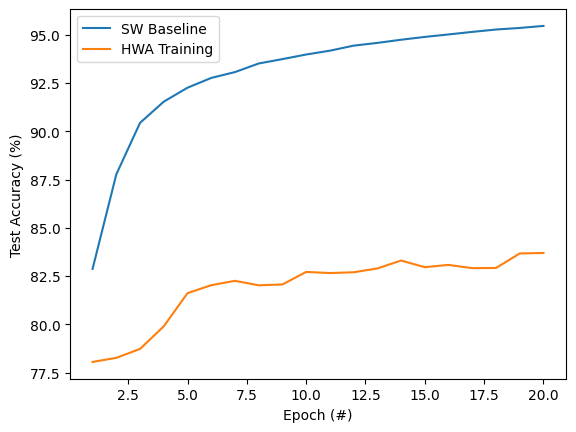

In [16]:
# Plot test accuracies
plot_network_performance(xs, [full_weights_sw["test_accs"], full_weights_hwa["test_accs"]], "Epoch (#)", "Test Accuracy (%)", legend_texts=["SW Baseline", "HWA Training"])

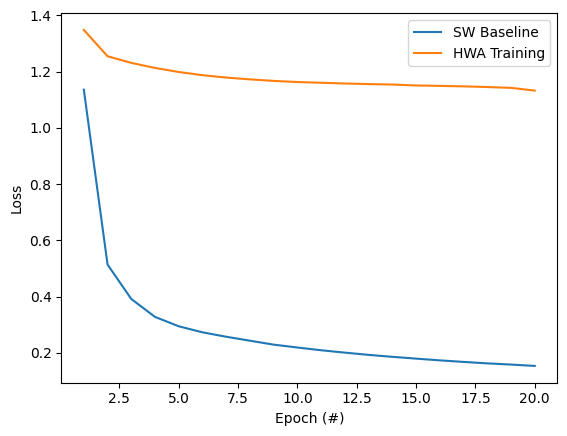

In [17]:
# Plot training losses
plot_network_performance(xs, [full_weights_sw["train_losss"], full_weights_hwa["train_losss"]], "Epoch (#)", "Loss", legend_texts=["SW Baseline", "HWA Training"])

## Conclusion

We were able to train a neural network with hardware-aware considerations solely by specifying the `xbtorch_patch_network` flag. Compared to a software baseline network, the hardware-aware (HWA) training network lags behind in terms of neural network accuracy. This is expected for multiple reasons, especially at the network scale being demonstrated in this example. One such reason is that the software network has 32-bit floating point weights, whereas our HWA network only has ternary weights, which are technically 1.58-bit.

In the following examples, we will use checkpoints from the same two networks and see how XBTorch can be utilized to investigate underlying loss landscapes, which can be used as a way to measure device-network interactions.

## References

1. Wu, S., Li, G., Chen, F., & Shi, L. (2018). Training and inference with integers in deep neural networks. arXiv preprint arXiv:1802.04680.
2. Yousuf, O., Glasmann, A. L., Mazzoni, A. L., Najmaei, S., & Adam, G. C. (2025). Robust Hardware-Aware Neural Networks for FeFET-based Accelerators. IEEE Transactions on Nanotechnology.